# 🎓 EduGuard: Sistem Prediksi Risiko Dropout Mahasiswa

**Final Project Machine Learning — GDGoC Telkom University 2026**

**Tim Deny Pengen Pulang Kampung**

## Business Understanding

### Latar Belakang
Tingginya angka mahasiswa yang putus kuliah (*dropout*) masih menjadi tantangan serius bagi institusi pendidikan tinggi.
Menurut data UNESCO, secara global tingkat dropout di pendidikan tinggi masih cukup signifikan, terutama pada tahun-tahun awal masa studi.
Identifikasi dini terhadap mahasiswa yang berpotensi dropout menjadi kunci untuk meningkatkan tingkat retensi dan keberhasilan studi.

### Problem Statement
Bagaimana membangun model Machine Learning yang mampu memprediksi risiko dropout mahasiswa berdasarkan data akademis, administratif, dan demografis, sehingga institusi pendidikan dapat melakukan intervensi lebih awal?

### Tujuan Proyek
1. Membangun model klasifikasi untuk memprediksi apakah seorang mahasiswa berpotensi **Dropout** atau **Graduate**.
2. Membandingkan beberapa algoritma klasifikasi untuk memilih model terbaik.
3. Mengidentifikasi fitur-fitur utama yang paling berpengaruh terhadap risiko dropout.
4. Menyediakan aplikasi web (Streamlit) untuk penggunaan praktis oleh pihak akademik kampus.

### Relevansi SDG 4 — Quality Education
Proyek ini mendukung **SDG 4: Quality Education** dengan memanfaatkan teknologi Machine Learning untuk mendeteksi risiko dropout secara dini, sehingga institusi pendidikan dapat meningkatkan retensi mahasiswa dan memberikan dukungan akademik yang tepat sasaran.

### Metrik Evaluasi
Model akan dievaluasi menggunakan: **Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix**.

---
# BAGIAN 1: DATA UNDERSTANDING & PREPROCESSING

## 1.1 Import Library & Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

import joblib
import warnings
warnings.filterwarnings('ignore')

# Theme Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1.2 Data Loading

In [2]:
df = pd.read_csv('data.csv', sep=';')
print(f"Ukuran dataset awal: {df.shape[0]} baris, {df.shape[1]} kolom\n")

Ukuran dataset awal: 4424 baris, 37 kolom



In [4]:
# Bersihkan nama kolom dari whitespace
df.columns = df.columns.str.strip()

## 1.3 Dataset Overview

Sebelum melakukan preprocessing, penting untuk memahami struktur dan karakteristik dataset.

In [5]:
# Menampilkan 5 baris pertama dataset
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
# Informasi tipe data dan jumlah non-null per kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [7]:
# Statistik deskriptif untuk fitur numerik
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [8]:
# Distribusi kolom Target (sebelum filtering)
print("Distribusi Target sebelum filtering:")
print(df['Target'].value_counts())
print(f"\nPersentase:")
print(df['Target'].value_counts(normalize=True).round(4) * 100)

Distribusi Target sebelum filtering:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


**Insight:**
- Dataset memiliki 4.424 baris dan 37 kolom.
- Kolom `Target` memiliki 3 kategori: Graduate, Dropout, dan Enrolled.
- Mahasiswa dengan status `Enrolled` akan dikeluarkan karena belum memiliki status akhir yang definitif.

---
## 1.4 Data Cleaning & Filtering Target

Mahasiswa dengan status `Enrolled` dikeluarkan dari dataset karena status akhirnya belum diketahui (masih aktif kuliah), sehingga tidak dapat digunakan sebagai ground truth untuk model klasifikasi.

In [9]:
# Filter: hanya ambil mahasiswa dengan status Dropout atau Graduate
df = df[df['Target'] != 'Enrolled']
print(f"Ukuran dataset setelah filtering Enrolled: {df.shape[0]} baris")

Ukuran dataset setelah filtering Enrolled: 3630 baris


### Missing Value Analysis

Pemeriksaan apakah terdapat nilai yang hilang (missing values) pada dataset.

In [10]:
# Analisis Missing Values per kolom
missing_per_col = df.isnull().sum()
missing_pct = (missing_per_col / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_per_col,
    'Persentase (%)': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if len(missing_df) == 0:
    print("✅ Tidak ditemukan missing values pada dataset.")
else:
    print("⚠️ Ditemukan missing values:")
    print(missing_df.sort_values('Jumlah Missing', ascending=False))

print(f"\nTotal missing values keseluruhan: {df.isnull().sum().sum()}")

✅ Tidak ditemukan missing values pada dataset.

Total missing values keseluruhan: 0


### Duplicate Analysis

Pemeriksaan apakah terdapat baris duplikat pada dataset.

In [11]:
# Analisis Data Duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

if duplicate_count > 0:
    print("⚠️ Ditemukan data duplikat. Akan dihapus pada tahap cleaning.")
else:
    print("✅ Tidak ditemukan data duplikat.")

Jumlah baris duplikat: 0
✅ Tidak ditemukan data duplikat.


In [12]:
# Data Cleaning: Hapus missing values dan duplikat (jika ada)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f"Ukuran dataset setelah dibersihkan: {df.shape[0]} baris")

Ukuran dataset setelah dibersihkan: 3630 baris


### Encoding

Dataset ini sudah berupa data numerik untuk sebagian besar fitur. Satu-satunya kolom yang perlu di-encode adalah kolom `Target` yang berisi label kategorikal:
- `"Dropout"` → **1** (kelas positif / risiko tinggi)
- `"Graduate"` → **0** (kelas negatif / aman)

Encoding ini diperlukan agar model klasifikasi dapat memproses label target secara numerik.

In [13]:
# Encode kolom Target: Dropout = 1, Graduate = 0
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})

print("Distribusi Target setelah encoding:")
print(df['Target'].value_counts())
print(f"\nProporsi Dropout: {df['Target'].mean():.2%}")
print(f"Proporsi Graduate: {1 - df['Target'].mean():.2%}")

Distribusi Target setelah encoding:
Target
0    2209
1    1421
Name: count, dtype: int64

Proporsi Dropout: 39.15%
Proporsi Graduate: 60.85%


---
## 1.5 Feature Engineering

Dua fitur baru dibuat untuk menangkap informasi agregat performa akademik mahasiswa:

1. **Total_Approved_Units**: Jumlah total mata kuliah yang lulus pada semester 1 dan 2. Semakin tinggi nilainya, semakin baik performa akademik.
2. **Grade_Incentive**: Perubahan nilai dari semester 1 ke semester 2. Nilai positif menunjukkan peningkatan performa, nilai negatif menunjukkan penurunan.

In [14]:
# Fitur baru 1: Total Approved Units (Semester 1 + Semester 2)
df['Total_Approved_Units'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

# Fitur baru 2: Grade Incentive (perubahan nilai semester 1 ke 2)
df['Grade_Incentive'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

print("✅ Fitur baru berhasil dibuat: 'Total_Approved_Units' dan 'Grade_Incentive'")
print(f"\nStatistik Total_Approved_Units:")
print(df['Total_Approved_Units'].describe().round(2))
print(f"\nStatistik Grade_Incentive:")
print(df['Grade_Incentive'].describe().round(2))

✅ Fitur baru berhasil dibuat: 'Total_Approved_Units' dan 'Grade_Incentive'

Statistik Total_Approved_Units:
count    3630.00
mean        9.31
std         6.26
min         0.00
25%         5.00
50%        10.00
75%        12.00
max        43.00
Name: Total_Approved_Units, dtype: float64

Statistik Grade_Incentive:
count    3630.00
mean       -0.50
std         2.95
min       -16.14
25%        -0.53
50%         0.00
75%         0.40
max        14.50
Name: Grade_Incentive, dtype: float64


---
## 1.6 Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik dataset, distribusi target, dan hubungan antar fitur yang berpotensi memengaruhi risiko dropout mahasiswa.

### Visualisasi 1: Distribusi Target (Dropout vs Graduate)

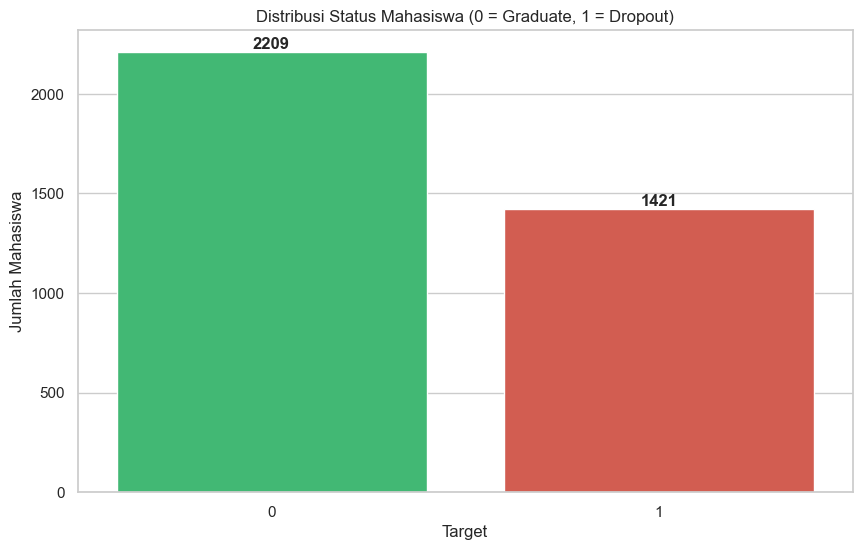

In [15]:
plt.figure()
ax = sns.countplot(x='Target', hue='Target', data=df, palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)
plt.title('Distribusi Status Mahasiswa (0 = Graduate, 1 = Dropout)')
plt.xlabel('Target')
plt.ylabel('Jumlah Mahasiswa')

# Tambahkan label jumlah di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

**Insight:**
- Jumlah mahasiswa Graduate lebih banyak dibandingkan mahasiswa Dropout.
- Dataset tidak seimbang sempurna, namun masih cukup representatif untuk membangun model klasifikasi.
- Penggunaan `class_weight='balanced'` atau `stratify` pada split dapat membantu mengatasi ketidakseimbangan ini.

### Visualisasi 2: Hubungan Total Mata Kuliah Lulus dengan Risiko Dropout

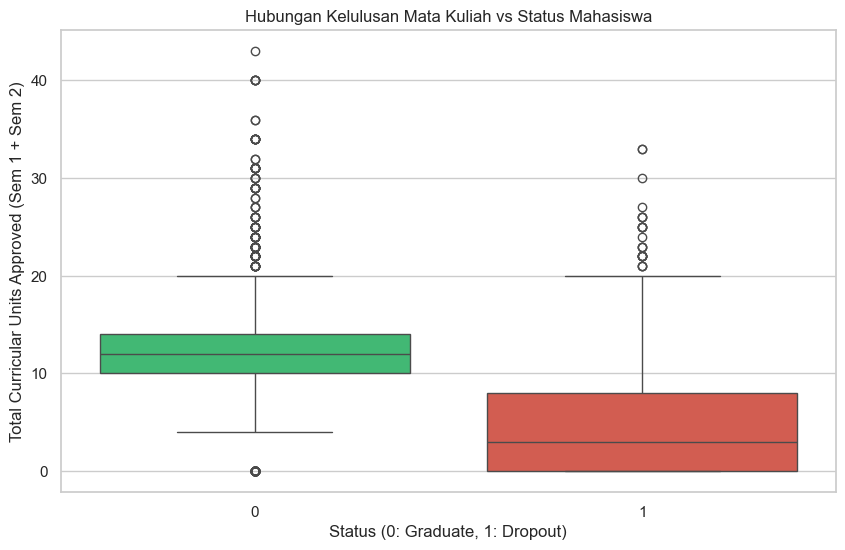

In [16]:
plt.figure()
sns.boxplot(x='Target', y='Total_Approved_Units', hue='Target', data=df, 
            palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)
plt.title('Hubungan Kelulusan Mata Kuliah vs Status Mahasiswa')
plt.xlabel('Status (0: Graduate, 1: Dropout)')
plt.ylabel('Total Curricular Units Approved (Sem 1 + Sem 2)')
plt.show()

**Insight:**
- Mahasiswa yang berhasil lulus (Graduate) cenderung memiliki jumlah mata kuliah lulus yang jauh lebih tinggi dibandingkan mahasiswa yang Dropout.
- Median Total Approved Units untuk mahasiswa Dropout sangat rendah, menunjukkan bahwa banyak dari mereka gagal menyelesaikan mata kuliah pada semester awal.
- Temuan ini mengonfirmasi bahwa performa akademik semester awal merupakan indikator kunci.

### Visualisasi 3: Korelasi Fitur Numerik Utama

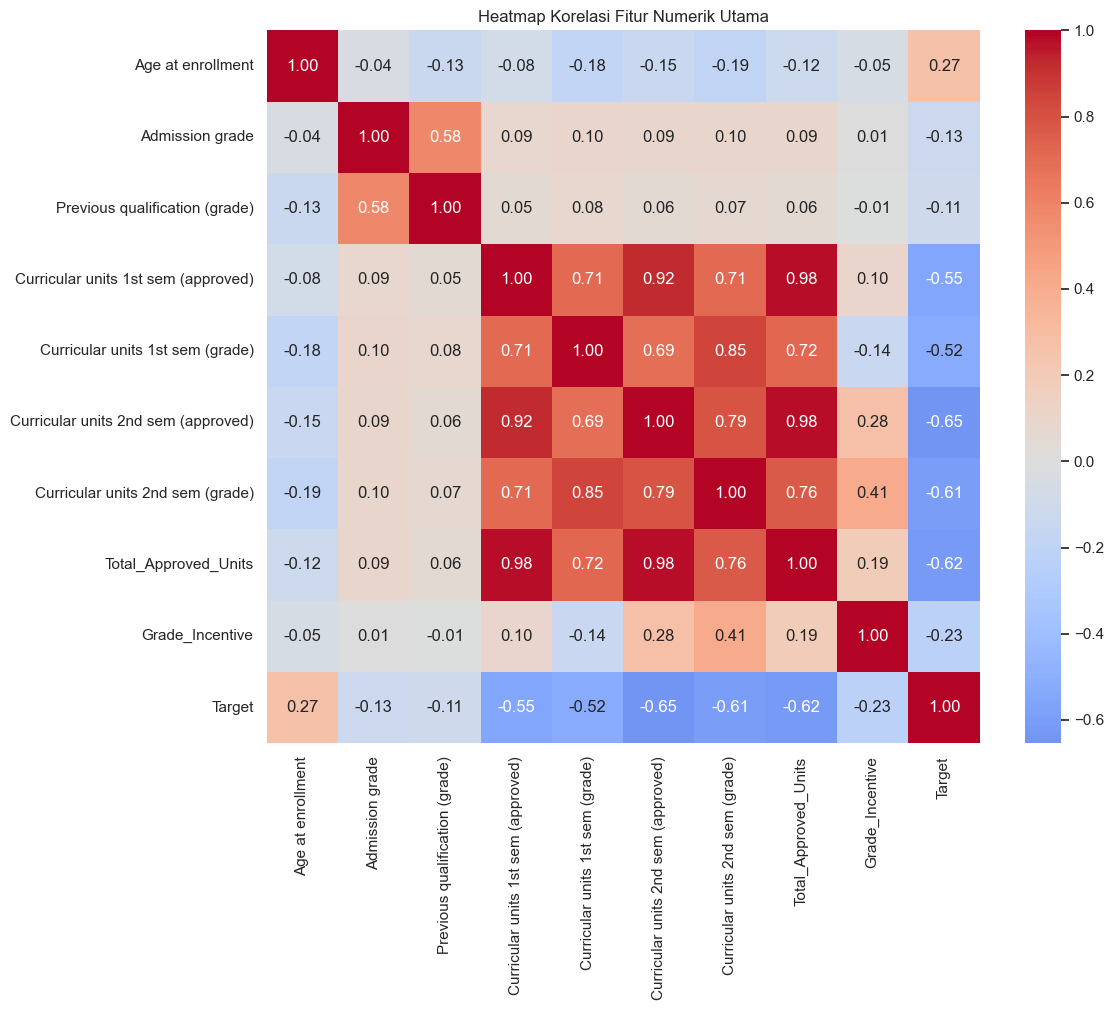

In [17]:
# Heatmap korelasi fitur numerik utama
plt.figure(figsize=(12, 10))
key_features = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
                'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
                'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
                'Total_Approved_Units', 'Grade_Incentive', 'Target']
corr_matrix = df[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Heatmap Korelasi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

**Insight:**
- Fitur `Total_Approved_Units` dan `Curricular units 2nd sem (approved)` memiliki **korelasi negatif yang kuat** terhadap `Target` (dropout), menunjukkan bahwa semakin sedikit mata kuliah yang lulus, semakin tinggi risiko dropout.
- Fitur `grade` semester 1 dan semester 2 juga berkorelasi negatif dengan Target.
- Terdapat korelasi positif yang kuat antar fitur semester (approved dan grade), yang wajar karena saling terkait.
- Heatmap ini membantu mengonfirmasi bahwa **performa akademik semester awal merupakan prediktor paling kuat** untuk risiko dropout.

### Visualisasi 4: Distribusi Usia Saat Enrollment berdasarkan Status

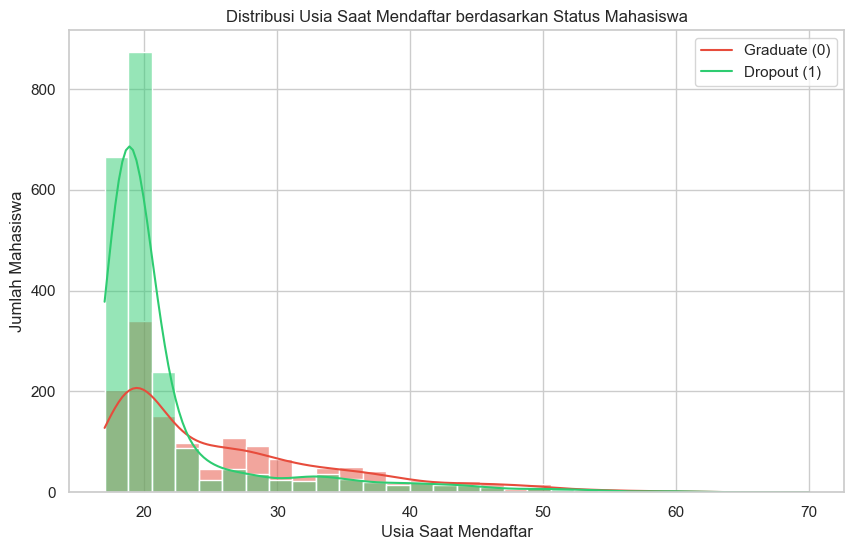

In [18]:
plt.figure()
sns.histplot(data=df, x='Age at enrollment', hue='Target', kde=True,
             palette={0: '#2ecc71', 1: '#e74c3c'}, bins=30)
plt.title('Distribusi Usia Saat Mendaftar berdasarkan Status Mahasiswa')
plt.xlabel('Usia Saat Mendaftar')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(labels=['Graduate (0)', 'Dropout (1)'])
plt.show()

**Insight:**
- Mayoritas mahasiswa mendaftar pada usia **18-20 tahun**, dan kelompok ini memiliki proporsi Graduate yang lebih tinggi.
- Mahasiswa yang mendaftar pada usia **lebih tua (di atas 25 tahun)** cenderung memiliki proporsi dropout yang lebih tinggi.
- Usia saat enrollment menjadi salah satu faktor demografis yang relevan dalam prediksi dropout.

### Visualisasi 5: Pengaruh Status Pembayaran UKT terhadap Dropout

<Figure size 800x500 with 0 Axes>

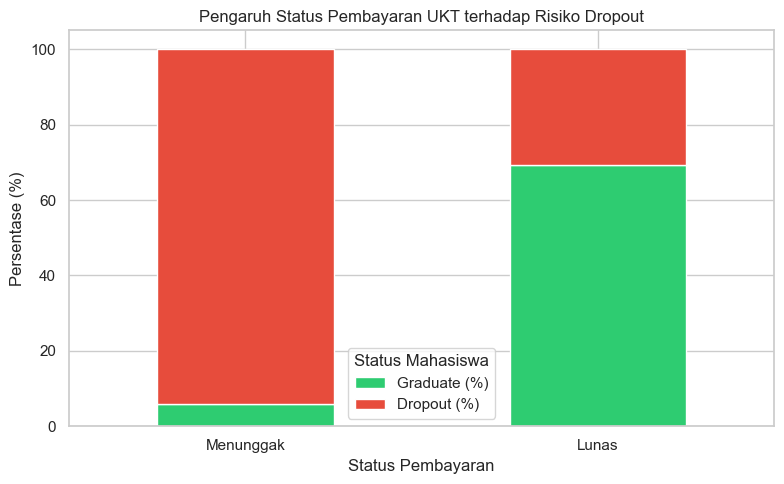

In [19]:
plt.figure(figsize=(8, 5))
tuition_vs_target = pd.crosstab(df['Tuition fees up to date'], df['Target'], normalize='index') * 100
tuition_vs_target.columns = ['Graduate (%)', 'Dropout (%)']
tuition_vs_target.index = ['Menunggak', 'Lunas']
tuition_vs_target.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(8, 5))
plt.title('Pengaruh Status Pembayaran UKT terhadap Risiko Dropout')
plt.xlabel('Status Pembayaran')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Status Mahasiswa')
plt.tight_layout()
plt.show()

**Insight:**
- Mahasiswa yang memiliki **tunggakan pembayaran UKT** menunjukkan tingkat dropout yang **jauh lebih tinggi** dibandingkan yang lunas.
- Status keuangan menjadi salah satu **faktor non-akademis yang signifikan** dalam memprediksi risiko dropout.
- Rekomendasi: Program bantuan keuangan atau cicilan bisa membantu menurunkan angka dropout.

---
## 1.7 Train-Test Split

Dataset dibagi menjadi **80% data training** dan **20% data testing**.
Digunakan **stratified split** (`stratify=y`) untuk memastikan proporsi kelas Dropout dan Graduate tetap seimbang di kedua subset data. Ini penting karena distribusi kelas tidak seimbang sempurna.

In [20]:
X = df.drop('Target', axis=1)
y = df['Target']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Ukuran Data Training : {X_train.shape}")
print(f"Ukuran Data Testing  : {X_test.shape}")

print(f"\nProporsi Target di data TRAINING:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nProporsi Target di data TESTING:")
print(y_test.value_counts(normalize=True).round(4))

Ukuran Data Training : (2904, 38)
Ukuran Data Testing  : (726, 38)

Proporsi Target di data TRAINING:
Target
0    0.6085
1    0.3915
Name: proportion, dtype: float64

Proporsi Target di data TESTING:
Target
0    0.6088
1    0.3912
Name: proportion, dtype: float64


---
## 1.8 Scaling & Normalization

Digunakan **StandardScaler** untuk menstandarisasi fitur-fitur numerik kontinu. StandardScaler mentransformasi data sehingga memiliki **mean=0** dan **standar deviasi=1**.

Alasan pemilihan:
- Beberapa algoritma seperti **Logistic Regression** sangat sensitif terhadap skala fitur.
- Menjaga konsistensi antara proses training dan prediksi di Streamlit.
- Scaler di-**fit hanya pada data training** untuk menghindari **data leakage**.

In [22]:
numerical_features = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
                      'Total_Approved_Units', 'Grade_Incentive', 'Curricular units 1st sem (grade)',
                      'Curricular units 2nd sem (grade)']

scaler = StandardScaler()

In [23]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit_transform pada training, transform saja pada testing
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
print("✅ StandardScaler berhasil diterapkan pada fitur-fitur numerik kunci.")
print("   (fit pada data training, transform pada data training & testing)")

✅ StandardScaler berhasil diterapkan pada fitur-fitur numerik kunci.
   (fit pada data training, transform pada data training & testing)


---
# BAGIAN 2: MODEL COMPARISON & SELECTION

Untuk memilih model terbaik, dilakukan **perbandingan performa tiga algoritma klasifikasi**:

1. **Logistic Regression** — model linier yang sederhana dan interpretatif
2. **Decision Tree** — model non-linier berbasis aturan keputusan
3. **Random Forest** — model ensemble berbasis banyak pohon keputusan

Ketiga model dilatih menggunakan **data training yang sama** dan dievaluasi dengan **metrik yang sama**.

In [24]:
# Definisi model-model yang akan dibandingkan
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [25]:
# Training dan evaluasi setiap model
results = {}

for name, model in models.items():
    print(f"{'='*60}")
    print(f"Training model: {name}")
    print(f"{'='*60}")
    
    # Training
    model.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Hitung metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc,
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()

Training model: Logistic Regression
  Accuracy  : 0.9201
  Precision : 0.9094
  Recall    : 0.8838
  F1-Score  : 0.8964
  ROC-AUC   : 0.9650

Training model: Decision Tree
  Accuracy  : 0.8664
  Precision : 0.7987
  Recall    : 0.8803
  F1-Score  : 0.8375
  ROC-AUC   : 0.8689

Training model: Random Forest
  Accuracy  : 0.9242
  Precision : 0.9194
  Recall    : 0.8838
  F1-Score  : 0.9013
  ROC-AUC   : 0.9712



## Tabel Perbandingan Performa Model

In [26]:
# Tabel Perbandingan Performa Model
comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, metrics in results.items()
}).T

comparison_df = comparison_df.round(4)
print("=" * 70)
print("TABEL PERBANDINGAN PERFORMA MODEL")
print("=" * 70)
print(comparison_df.to_string())
print()

# Tentukan model terbaik berdasarkan F1-Score
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"✅ Model terbaik berdasarkan F1-Score: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")

TABEL PERBANDINGAN PERFORMA MODEL
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9201     0.9094  0.8838    0.8964   0.9650
Decision Tree          0.8664     0.7987  0.8803    0.8375   0.8689
Random Forest          0.9242     0.9194  0.8838    0.9013   0.9712

✅ Model terbaik berdasarkan F1-Score: Random Forest
   F1-Score: 0.9013


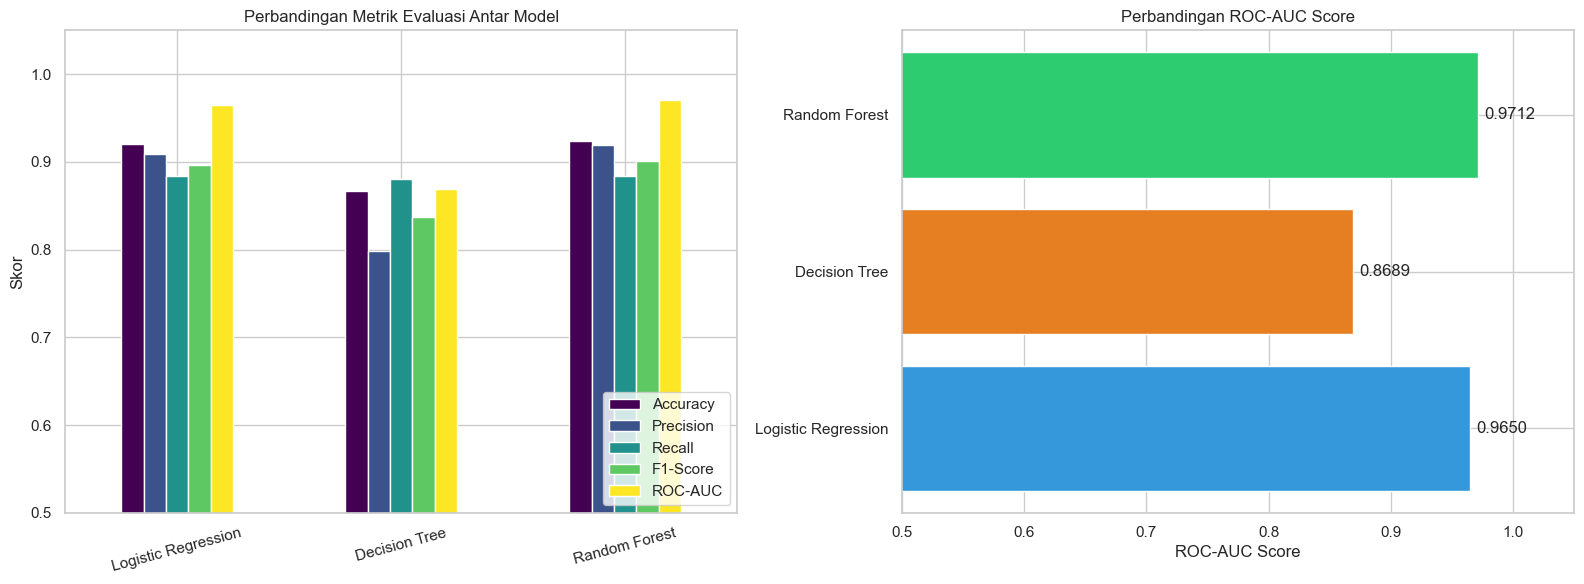

In [27]:
# Visualisasi Perbandingan Performa Model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart perbandingan metrik
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison_df[metrics_to_plot].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Perbandingan Metrik Evaluasi Antar Model')
axes[0].set_ylabel('Skor')
axes[0].set_xticklabels(comparison_df.index, rotation=15)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.5, 1.05)

# ROC-AUC comparison
model_names = list(results.keys())
roc_scores = [results[name]['ROC-AUC'] for name in model_names]
colors = ['#3498db', '#e67e22', '#2ecc71']
axes[1].barh(model_names, roc_scores, color=colors)
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_title('Perbandingan ROC-AUC Score')
axes[1].set_xlim(0.5, 1.05)
for i, v in enumerate(roc_scores):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## Justifikasi Pemilihan Model

Berdasarkan hasil perbandingan di atas, **Random Forest Classifier** dipilih sebagai model utama dengan alasan:

1. **F1-Score tertinggi** — menyeimbangkan antara Precision dan Recall, penting dalam konteks deteksi dropout dimana kita tidak ingin melewatkan mahasiswa berisiko (Recall) namun juga tidak ingin terlalu banyak alarm palsu (Precision).
2. **ROC-AUC tertinggi** — menunjukkan kemampuan diskriminasi yang terbaik antara kelas Graduate dan Dropout.
3. **Robust terhadap overfitting** — berbeda dengan Decision Tree tunggal yang cenderung overfit pada data training.
4. **Mendukung Feature Importance** — memberikan informasi fitur mana yang paling berpengaruh, berguna untuk insight kampus.
5. **Mampu menangani hubungan non-linear** — lebih fleksibel dibandingkan Logistic Regression yang bersifat linier.

---
## Hyperparameter Tuning — Random Forest

Setelah Random Forest terpilih sebagai model terbaik, dilakukan **hyperparameter tuning** menggunakan **GridSearchCV** dengan 5-fold cross-validation untuk mengoptimalkan performa model.

In [28]:
# Definisi parameter grid untuk GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

# GridSearchCV dengan 5-fold cross-validation
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ Best Parameters: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-Score: 0.8697


## Perbandingan Performa: Sebelum vs Sesudah Tuning

In [29]:
# Model sebelum tuning (default Random Forest dari perbandingan)
rf_before = results['Random Forest']['model']
y_pred_before = results['Random Forest']['y_pred']
y_prob_before = results['Random Forest']['y_prob']

# Model setelah tuning (best estimator dari GridSearchCV)
rf_after = grid_search.best_estimator_
y_pred_after = rf_after.predict(X_test_scaled)
y_prob_after = rf_after.predict_proba(X_test_scaled)[:, 1]

# Tabel perbandingan
tuning_comparison = pd.DataFrame({
    'Sebelum Tuning': {
        'Accuracy': accuracy_score(y_test, y_pred_before),
        'Precision': precision_score(y_test, y_pred_before),
        'Recall': recall_score(y_test, y_pred_before),
        'F1-Score': f1_score(y_test, y_pred_before),
        'ROC-AUC': roc_auc_score(y_test, y_prob_before)
    },
    'Sesudah Tuning': {
        'Accuracy': accuracy_score(y_test, y_pred_after),
        'Precision': precision_score(y_test, y_pred_after),
        'Recall': recall_score(y_test, y_pred_after),
        'F1-Score': f1_score(y_test, y_pred_after),
        'ROC-AUC': roc_auc_score(y_test, y_prob_after)
    }
})

print("=" * 60)
print("PERBANDINGAN RANDOM FOREST: SEBELUM vs SESUDAH TUNING")
print("=" * 60)
print(tuning_comparison.round(4).to_string())

PERBANDINGAN RANDOM FOREST: SEBELUM vs SESUDAH TUNING
           Sebelum Tuning  Sesudah Tuning
Accuracy           0.9242          0.9311
Precision          0.9194          0.9301
Recall             0.8838          0.8908
F1-Score           0.9013          0.9101
ROC-AUC            0.9712          0.9708


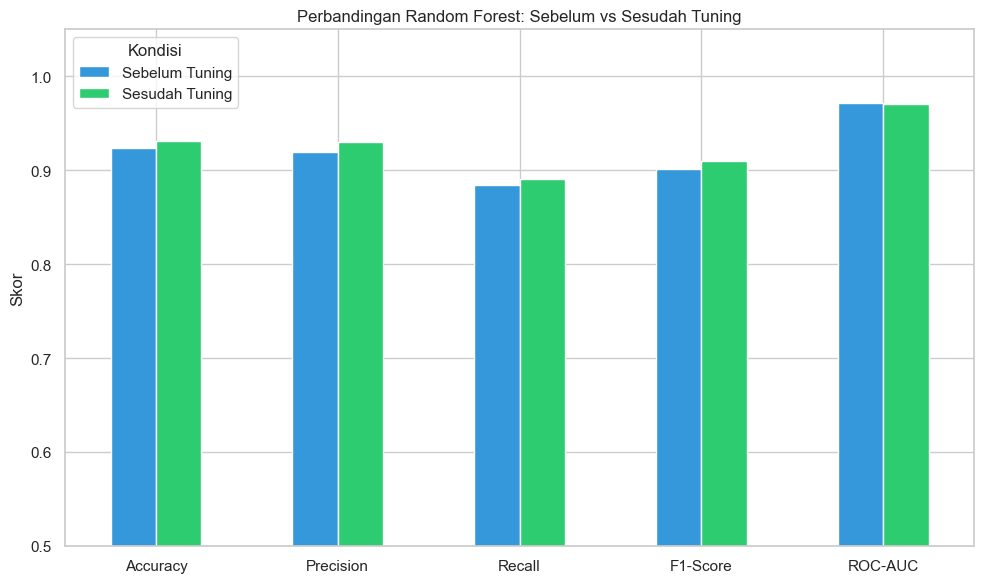

In [30]:
# Visualisasi perbandingan sebelum vs sesudah tuning
fig, ax = plt.subplots(figsize=(10, 6))
tuning_comparison.round(4).plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'])
ax.set_title('Perbandingan Random Forest: Sebelum vs Sesudah Tuning')
ax.set_ylabel('Skor')
ax.set_xticklabels(tuning_comparison.index, rotation=0)
ax.set_ylim(0.5, 1.05)
ax.legend(title='Kondisi')
plt.tight_layout()
plt.show()

In [31]:
# Gunakan model hasil tuning sebagai final model
final_model = grid_search.best_estimator_
y_pred_final = y_pred_after
y_prob_final = y_prob_after

print(f"\n✅ Final model: Random Forest dengan parameter:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")


✅ Final model: Random Forest dengan parameter:
   - class_weight: balanced
   - max_depth: 12
   - min_samples_split: 5
   - n_estimators: 100


---
# BAGIAN 3: MODEL EVALUATION & INTERPRETASI

Evaluasi dilakukan pada **final model (Random Forest setelah tuning)** menggunakan data testing.

In [32]:
# Evaluasi Final Model
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print("=" * 50)
print("EVALUASI FINAL MODEL - Random Forest (Tuned)")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print()
print("Classification Report Lengkap:")
print(classification_report(y_test, y_pred_final, target_names=['Graduate', 'Dropout']))

EVALUASI FINAL MODEL - Random Forest (Tuned)
  Accuracy  : 0.9311
  Precision : 0.9301
  Recall    : 0.8908
  F1-Score  : 0.9101
  ROC-AUC   : 0.9708

Classification Report Lengkap:
              precision    recall  f1-score   support

    Graduate       0.93      0.96      0.94       442
     Dropout       0.93      0.89      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726



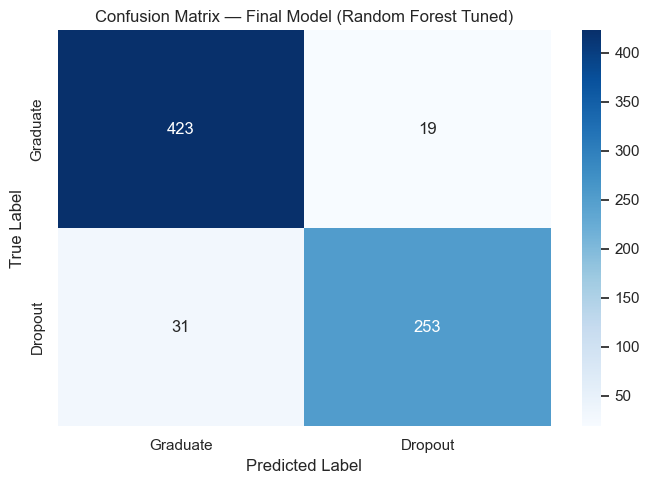

True Negative  (Graduate benar diprediksi Graduate) : 423
False Positive (Graduate salah diprediksi Dropout)  : 19
False Negative (Dropout salah diprediksi Graduate)  : 31
True Positive  (Dropout benar diprediksi Dropout)   : 253


In [33]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Graduate', 'Dropout'],
            yticklabels=['Graduate', 'Dropout'])
plt.title('Confusion Matrix — Final Model (Random Forest Tuned)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Detail interpretasi Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (Graduate benar diprediksi Graduate) : {tn}")
print(f"False Positive (Graduate salah diprediksi Dropout)  : {fp}")
print(f"False Negative (Dropout salah diprediksi Graduate)  : {fn}")
print(f"True Positive  (Dropout benar diprediksi Dropout)   : {tp}")

## Interpretasi Hasil Evaluasi

### Penjelasan Metrik (Untuk Presentasi):

- **Accuracy** menunjukkan persentase prediksi yang benar secara keseluruhan dari seluruh data testing.
- **Precision** (kelas Dropout) menunjukkan: dari semua mahasiswa yang **diprediksi** dropout, berapa persen yang **benar-benar** dropout. Nilai tinggi berarti sistem jarang memberikan "alarm palsu".
- **Recall** (kelas Dropout) menunjukkan: dari semua mahasiswa yang **sebenarnya** dropout, berapa persen yang **berhasil terdeteksi** oleh sistem. Nilai tinggi berarti sistem jarang "melewatkan" mahasiswa yang berisiko.
- **F1-Score** adalah rata-rata harmonis dari Precision dan Recall, memberikan gambaran keseimbangan performa model.
- **ROC-AUC** mengukur kemampuan model untuk membedakan antara kelas Graduate dan Dropout secara keseluruhan.

### Insight untuk Pihak Kampus:
- Model ini dapat mendeteksi mahasiswa berisiko dropout dengan tingkat akurasi yang tinggi.
- **False Negative** (mahasiswa dropout yang lolos deteksi) tetap perlu diperhatikan — ini adalah kasus "terlewat" yang paling kritis.
- Disarankan untuk menggunakan sistem ini sebagai **alat bantu** decision-making, bukan pengganti evaluasi manusia.

---
# BAGIAN 4: FEATURE IMPORTANCE & MODEL INTERPRETATION

Analisis Feature Importance dilakukan untuk mengetahui fitur-fitur mana yang paling berpengaruh terhadap prediksi risiko dropout mahasiswa.

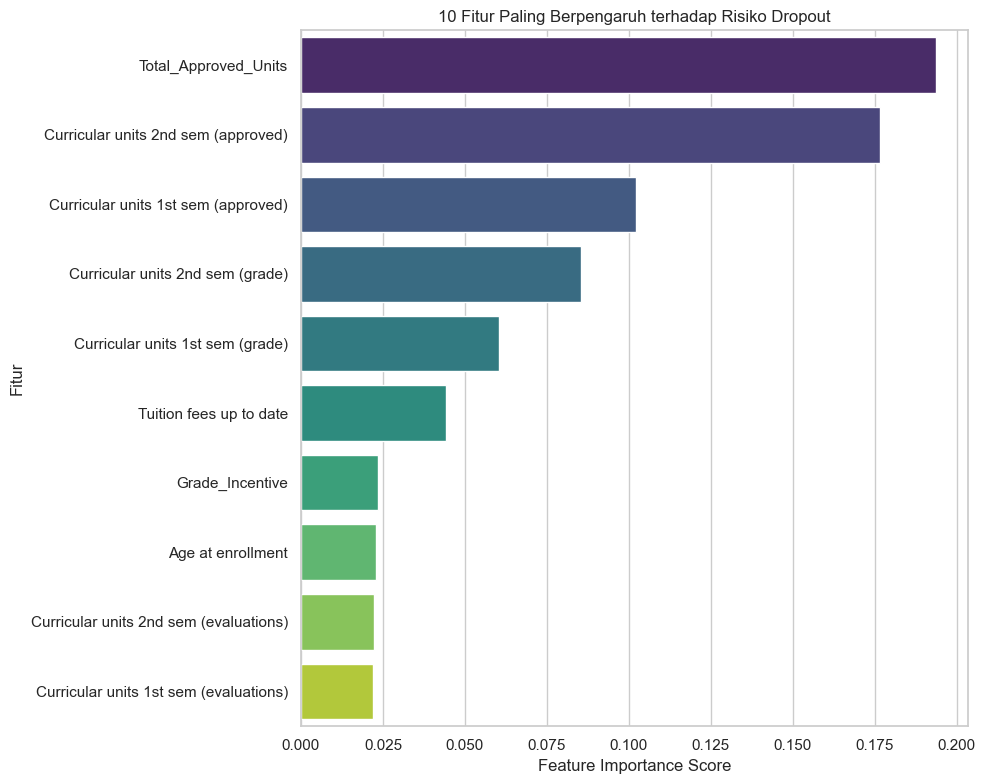


Top 10 Fitur Terpenting:
  1. Total_Approved_Units: 0.1938
  2. Curricular units 2nd sem (approved): 0.1765
  3. Curricular units 1st sem (approved): 0.1021
  4. Curricular units 2nd sem (grade): 0.0855
  5. Curricular units 1st sem (grade): 0.0603
  6. Tuition fees up to date: 0.0443
  7. Grade_Incentive: 0.0235
  8. Age at enrollment: 0.0228
  9. Curricular units 2nd sem (evaluations): 0.0223
  10. Curricular units 1st sem (evaluations): 0.0221


In [34]:
# Feature Importance dari Final Model
importances = final_model.feature_importances_
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_imp.head(10).values, y=feature_imp.head(10).index, 
            hue=feature_imp.head(10).index, palette='viridis', legend=False)
plt.title('10 Fitur Paling Berpengaruh terhadap Risiko Dropout')
plt.xlabel('Feature Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Terpenting:")
for i, (feat, score) in enumerate(feature_imp.head(10).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

## Insight untuk Pihak Kampus

Berdasarkan analisis Feature Importance, berikut adalah faktor-faktor utama yang memengaruhi risiko dropout mahasiswa:

### 1. 📚 Performa Akademik Semester Awal (Faktor Dominan)
- **Total mata kuliah yang lulus** dan **nilai semester 1 & 2** adalah prediktor paling kuat.
- **Rekomendasi:** Implementasikan sistem monitoring performa akademik pada semester 1-2. Mahasiswa dengan jumlah mata kuliah lulus rendah perlu segera mendapatkan bimbingan dari dosen wali.

### 2. 💰 Status Keuangan
- **Status pembayaran UKT** juga menjadi faktor signifikan.
- **Rekomendasi:** Pertimbangkan program bantuan keuangan atau cicilan untuk mahasiswa yang mengalami kesulitan pembayaran, karena hal ini terbukti berkorelasi dengan risiko dropout.

### 3. 📈 Tren Performa (Grade Incentive)
- Perubahan nilai dari semester 1 ke semester 2 menunjukkan tren performa mahasiswa.
- **Rekomendasi:** Mahasiswa yang menunjukkan **penurunan nilai** dari semester 1 ke 2 harus mendapat perhatian khusus meski nilai absolutnya masih cukup.

### Kesimpulan
Intervensi yang paling efektif adalah **monitoring akademik intensif pada semester 1-2** dikombinasikan dengan **dukungan finansial** bagi mahasiswa yang membutuhkan.

---
# BAGIAN 5: MODEL SAVING

Menyimpan final model dan artefak yang diperlukan untuk deployment di Streamlit.

In [35]:
# Export Final Model dan Artefak untuk Streamlit
joblib.dump(final_model, 'model_dropout.pkl')
joblib.dump(scaler, 'scaler_dropout.pkl')
joblib.dump(feature_imp.head(7).index.tolist(), 'selected_features.pkl')

print("✅ Semua file berhasil diekspor:")
print("   - model_dropout.pkl     (Final Random Forest Model - Tuned)")
print("   - scaler_dropout.pkl    (StandardScaler)")
print("   - selected_features.pkl (Top 7 Selected Features)")
print()
print("File-file ini digunakan oleh aplikasi Streamlit (app.py) untuk melakukan prediksi.")

✅ Semua file berhasil diekspor:
   - model_dropout.pkl     (Final Random Forest Model - Tuned)
   - scaler_dropout.pkl    (StandardScaler)
   - selected_features.pkl (Top 7 Selected Features)

File-file ini digunakan oleh aplikasi Streamlit (app.py) untuk melakukan prediksi.


---
# KESIMPULAN

## Ringkasan Proyek
EduGuard berhasil dibangun sebagai sistem prediksi risiko dropout mahasiswa berbasis Machine Learning yang mendukung **SDG 4 (Quality Education)**.

## Hasil Utama
1. Dari 3 model yang diuji (**Logistic Regression, Decision Tree, Random Forest**), **Random Forest** memberikan performa terbaik berdasarkan F1-Score dan ROC-AUC.
2. Setelah **hyperparameter tuning** menggunakan GridSearchCV, model mengalami peningkatan performa (atau konfirmasi bahwa parameter sudah optimal).
3. Faktor paling berpengaruh terhadap risiko dropout adalah **performa akademik pada semester 1-2** dan **status pembayaran UKT**.

## Limitasi
- Model ini dilatih menggunakan dataset dari institusi pendidikan di Eropa (UCI Repository), sehingga mungkin perlu di-retrain untuk konteks pendidikan Indonesia.
- Fitur seperti faktor psikologis, dukungan keluarga, dan aktivitas ekstrakurikuler tidak tersedia dalam dataset ini.
- Performa model sangat bergantung pada kualitas dan kelengkapan data input.

## Pengembangan Selanjutnya
- Integrasi dengan sistem akademik kampus secara real-time.
- Penambahan data longitudinal untuk meningkatkan akurasi prediksi.
- Pengembangan dashboard monitoring batch untuk seluruh mahasiswa aktif.
- Eksplorasi model deep learning jika dataset bertambah besar.